# 06 — Experimento 3: Word2Vec mean pooling + Regresión Logística

Tercer experimento: representamos cada minuta por su **significado semántico promedio**, usando
embeddings Word2Vec preentrenados (`GoogleNews-300`). Cada palabra es un vector de 300 dimensiones
aprendido de un corpus enorme; palabras semánticamente parecidas quedan cerca en el espacio
("tightening" ≈ "restrictive") aunque no coocurran.

A diferencia de TF-IDF (cuenta strings exactos) y del lexicón LM (6 scores de tono), esta
representación captura **similitud semántica**. Hipótesis: debería generalizar mejor al drift de
vocabulario 2022–2025, donde TF-IDF colapsó, porque mapea palabras nuevas a regiones ya conocidas
del espacio vectorial.

**Input:** `data/processed/fomc_dataset.csv` + modelo `word2vec-google-news-300` (gensim, ~1.6 GB
la primera vez).

**Outputs:** figuras en `reports/figures/` (`06_confusion_val.png`, `06_confusion_test.png`).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import gensim.downloader as api
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 200

BASE_DIR       = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']
print('train:', len(train), '| val:', len(val), '| test:', len(test))

Matplotlib is building the font cache; this may take a moment.


train: 145 | val: 32 | test: 32


## Nota sobre el dataset y la evaluación

Mismo dataset que Exp 1 y 2: corpus **2000–2025** (209 docs) con etiquetas corregidas. Split
cronológico **train 2000–2017 (145), val 2018–2021 (32), test 2022–2025 (32)**, con las tres
clases en los tres conjuntos. La comparación de modelos se hace sobre **validación**; el test
(2022–2025) es generalización out-of-sample sobre un período difícil. val y test son chicos
(32 docs) → métricas algo ruidosas.

In [2]:
# Helper de evaluación (idéntico a notebooks 04 y 05).
def evaluar(y_true, y_pred, titulo, fname=None):
    clases_presentes = [c for c in LABEL_ORDER if c in set(y_true)]
    f1 = f1_score(y_true, y_pred, labels=clases_presentes, average='macro')

    print(titulo)
    print('accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print(f'f1_macro : {round(f1, 4)}  (promedio sobre {len(clases_presentes)} clases presentes: {clases_presentes})')
    print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    if fname:
        save_fig(fname)
    plt.show()
    return f1

## 1. Cargar embeddings Word2Vec preentrenados

`word2vec-google-news-300`: 3 millones de palabras/frases, vectores de 300 dimensiones,
entrenados sobre ~100 mil millones de palabras de Google News. La primera ejecución descarga
~1.6 GB (gensim lo cachea en `~/gensim-data/`).

In [ ]:
wv = api.load('word2vec-google-news-300')
DIM = wv.vector_size
print('Modelo cargado. Vocabulario:', len(wv.index_to_key), '| dim:', DIM)
# Sanity check semántico
print('Más similares a "inflation":', [w for w, _ in wv.most_similar('inflation', topn=5)])

Modelo cargado. Vocabulario: 3000000 | dim: 300
Más similares a "inflation": ['Inflation', 'inflationary_pressures', 'inflationary', 'inflationary_pressure', 'inflation_pressures']


## 2. Representación por documento: mean pooling

Cada minuta → promedio de los vectores de sus tokens presentes en el vocabulario de Word2Vec.
Los tokens fuera de vocabulario (OOV) se ignoran. Si un documento no tuviera ningún token
conocido, queda en el vector cero. Reportamos la cobertura (fracción de tokens en vocab) como
diagnóstico.

In [4]:
def doc_vector(text, wv, dim):
    toks = [t for t in str(text).split() if t in wv]
    if not toks:
        return np.zeros(dim, dtype=np.float32)
    return np.mean([wv[t] for t in toks], axis=0)

def coverage(text, wv):
    toks = str(text).split()
    if not toks:
        return 0.0
    return sum(1 for t in toks if t in wv) / len(toks)

# Cobertura OOV (diagnóstico)
cov = df['text'].apply(lambda t: coverage(t, wv))
print(f'Cobertura de vocabulario (tokens en Word2Vec): media {cov.mean():.1%}, mín {cov.min():.1%}')

# Matriz de features: un vector 300-dim por documento
X_train = np.vstack([doc_vector(t, wv, DIM) for t in train['text']])
X_val   = np.vstack([doc_vector(t, wv, DIM) for t in val['text']])
X_test  = np.vstack([doc_vector(t, wv, DIM) for t in test['text']])
y_train, y_val, y_test = train['label'], val['label'], test['label']
print('X_train:', X_train.shape, '(300 features semánticas)')

Cobertura de vocabulario (tokens en Word2Vec): media 97.0%, mín 95.1%


X_train: (145, 300) (300 features semánticas)


## 3. Baseline trivial

Misma cota inferior que en los experimentos anteriores: `DummyClassifier(strategy='prior')`.

Baseline (majority) — VAL
accuracy : 0.75
f1_macro : 0.2857  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00         4
         cut       0.00      0.00      0.00         4
        hold       0.75      1.00      0.86        24

    accuracy                           0.75        32
   macro avg       0.25      0.33      0.29        32
weighted avg       0.56      0.75      0.64        32



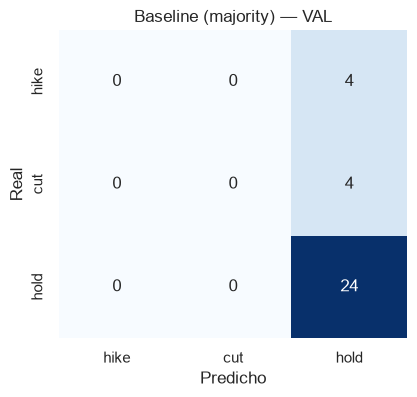

Baseline (majority) — TEST
accuracy : 0.4688
f1_macro : 0.2128  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         6
        hold       0.47      1.00      0.64        15

    accuracy                           0.47        32
   macro avg       0.16      0.33      0.21        32
weighted avg       0.22      0.47      0.30        32



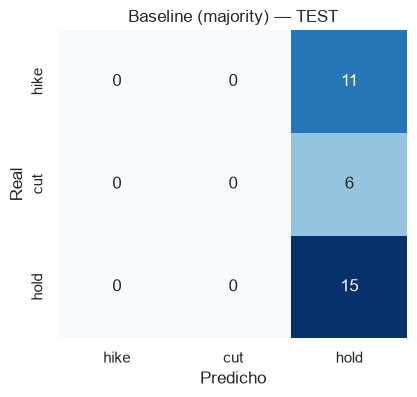

0.2127659574468085

In [5]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)
evaluar(y_val,  dummy.predict(X_val),  'Baseline (majority) — VAL')
evaluar(y_test, dummy.predict(X_test), 'Baseline (majority) — TEST')

## 4. Word2Vec + Regresión Logística

Pipeline: estandarizamos las 300 features densas (`StandardScaler`, ajustado solo en train) y
entrenamos la regresión logística multinomial con `class_weight='balanced'`. Tuneamos `C` sobre
validación.

In [6]:
C_grid = [0.01, 0.1, 1, 10]
resultados = []
for C in C_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=C, max_iter=1000, class_weight='balanced')),
    ])
    pipe.fit(X_train, y_train)
    f1_val = f1_score(y_val, pipe.predict(X_val),
                      labels=[c for c in LABEL_ORDER if c in set(y_val)], average='macro')
    resultados.append((C, f1_val))
    print(f'C={C:<5} -> F1-macro val = {f1_val:.4f}')

best_C = max(resultados, key=lambda t: t[1])[0]
print(f'\nMejor C (por F1-macro en val): {best_C}')

C=0.01  -> F1-macro val = 0.6028
C=0.1   -> F1-macro val = 0.6061
C=1     -> F1-macro val = 0.5841
C=10    -> F1-macro val = 0.5833

Mejor C (por F1-macro en val): 0.1


Word2Vec + LogReg (C=0.1) — VAL
accuracy : 0.7188
f1_macro : 0.6061  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.38      0.75      0.50         4
         cut       0.50      0.50      0.50         4
        hold       0.90      0.75      0.82        24

    accuracy                           0.72        32
   macro avg       0.59      0.67      0.61        32
weighted avg       0.78      0.72      0.74        32



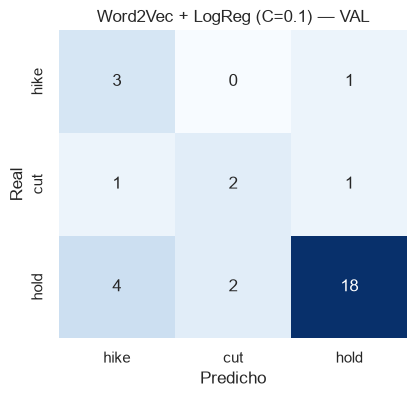

Word2Vec + LogReg (C=0.1) — TEST
accuracy : 0.4688
f1_macro : 0.3367  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.40      0.91      0.56        11
         cut       0.00      0.00      0.00         6
        hold       0.71      0.33      0.45        15

    accuracy                           0.47        32
   macro avg       0.37      0.41      0.34        32
weighted avg       0.47      0.47      0.40        32



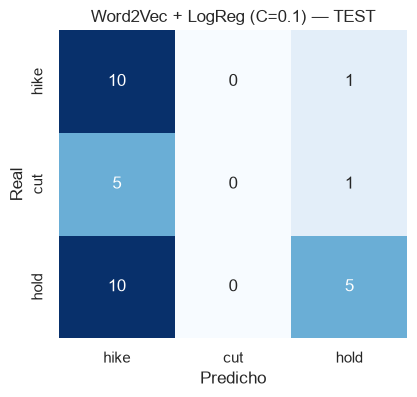

0.3367003367003367

In [7]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=best_C, max_iter=1000, class_weight='balanced')),
])
pipe.fit(X_train, y_train)

evaluar(y_val,  pipe.predict(X_val),  f'Word2Vec + LogReg (C={best_C}) — VAL',  '06_confusion_val.png')
evaluar(y_test, pipe.predict(X_test), f'Word2Vec + LogReg (C={best_C}) — TEST', '06_confusion_test.png')

## 5. Interpretación

**Word2Vec es el mejor modelo hasta ahora — y el primero que mejora en test.** F1-macro val
**0.606** (vs TF-IDF 0.519, LM 0.489) y test **0.337** (vs 0.213 y 0.154). Cobertura de
vocabulario 97% → el preprocesamiento (minúsculas, sin puntuación) no rompió el match con
GoogleNews.

Matriz de confusión **VAL** (real vs predicho):
```
        hike  cut  hold
hike  [  3    0    1 ]   3/4 hike
cut   [  1    2    1 ]   2/4 cut
hold  [  4    2   18 ]   18/24 hold
```
Detecta las **tres clases de forma balanceada** (hike F1 0.50, cut F1 0.50, hold F1 0.82) — a
diferencia de TF-IDF (cut F1 0.00) y de LM (sobre-predice hike).

Matriz de confusión **TEST**:
```
        hike  cut  hold
hike  [ 10    0    1 ]   10 de 11 hike (recall 0.91)
cut   [  5    0    1 ]   0 de 6 cut
hold  [ 10    0    5 ]   5 de 15 hold
```
**Hallazgo central: es el primer modelo que detecta los hikes en test (10 de 11).** TF-IDF y LM
colapsaban a `hold` (0 hikes). La representación semántica reconoce las subas inflacionarias de
2022–23 aunque el vocabulario sea nuevo: términos como "tightening"/"restrictive"/"raise" caen
cerca de las subas que el modelo vio en train (2004–06, 2015–18). **La semántica generaliza a
través del drift** donde el conteo exacto (TF-IDF) y el tono (LM) fallaban.

**Pero sigue sin detectar `cut` en test (0 de 6):** los recortes de 2024–25 son de normalización
en una economía sana — señal sutil — y el modelo los confunde con hike/hold. Además sobre-predice
hike (10 holds → hike) → accuracy modesta (0.47).

## Conclusión del experimento

Word2Vec **confirma la hipótesis**: los embeddings semánticos vencen el drift de vocabulario y son
los primeros en recuperar los hikes out-of-sample (10/11 en test), donde TF-IDF y LM colapsaban.
Es el mejor en val (0.606) y en test (0.337). El límite que queda —no detecta los recortes de
normalización 2024–25, y el mean pooling de ~4000 tokens diluye la señal— motiva FinBERT (Exp 4),
que usa **contexto** en vez de un promedio plano de embeddings.